# Cerința 2 — Procesarea datelor cu Spark SQL și DataFrame API

Această secțiune demonstrează utilizarea **Apache Spark** pentru procesarea, curățarea și analiza distribuită a setului de date Football Events. Vor fi folosite **ambele** interfețe Spark:
- **DataFrame API** — operații programatice (filter, groupBy, join, withColumn)
- **Spark SQL** — interogări SQL pe temp views


## 2.1 Inițializarea sesiunii Spark și încărcarea datelor

Creăm o sesiune Spark în modul local și citim cele două fișiere CSV cu inferarea automată a schemei.


In [1]:
import os
# Notebook-urile stau în subfolderul notebooks/; ne asigurăm că lucrăm din rădăcina proiectului
# (unde se află data/, models/, plots/), astfel încât toate căile relative să funcționeze.
if not os.path.isdir('data') and os.path.isdir(os.path.join('..', 'data')):
    os.chdir('..')
# Directoarele de output trebuie să existe înainte de orice savefig()/save()
os.makedirs('plots', exist_ok=True)
os.makedirs('models', exist_ok=True)
print('Working directory:', os.getcwd())

Working directory: /Users/stefan/Documents/football-events-analysis


### Configurarea sesiunii Spark

Creăm `SparkSession` — punctul de intrare unic către toate API-urile Spark (SQL, DataFrame, MLlib). Două configurări contează pe o mașină locală: `spark.driver.memory=4g` (datele și rezultatele agregărilor încap în memoria driver-ului) și `spark.sql.shuffle.partitions=8` (default-ul de 200 de partiții la shuffle e gândit pentru clustere mari; pe un laptop ar genera overhead inutil).


In [2]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, count, sum as spark_sum, avg, max as spark_max, min as spark_min,
    round as spark_round, when, isnan, isnull, desc, asc,
    countDistinct, lit, concat_ws, year, month
)
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.figsize'] = (12, 5)
matplotlib.rcParams['axes.spines.top'] = False
matplotlib.rcParams['axes.spines.right'] = False
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

spark = SparkSession.builder \
    .appName('FootballAnalysis_EDA') \
    .config('spark.driver.memory', '4g') \
    .config('spark.sql.shuffle.partitions', '8') \
    .getOrCreate()

spark.sparkContext.setLogLevel('ERROR')
print('Spark version:', spark.version)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/06/11 20:10:34 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 4.1.2


### Citirea datelor cu schema inferată

Citim ambele CSV-uri cu `inferSchema=True` (Spark face o trecere suplimentară peste fișier ca să deducă tipurile) și `nullValue='NA'` — dataset-ul folosește string-ul `'NA'` pentru valori lipsă, iar fără această opțiune Spark 4.x (ANSI mode activ implicit) ar arunca excepție la cast-ul `'NA'` → număr, în loc să întoarcă null.


In [3]:
events_df = spark.read.csv('data/events.csv', header=True, inferSchema=True, nullValue='NA')
ginf_df   = spark.read.csv('data/ginf.csv',   header=True, inferSchema=True, nullValue='NA')

print(f'events_df: {events_df.count():,} rânduri, {len(events_df.columns)} coloane')
print(f'ginf_df  : {ginf_df.count():,} rânduri, {len(ginf_df.columns)} coloane')

events_df: 941,009 rânduri, 22 coloane
ginf_df  : 10,112 rânduri, 18 coloane


In [4]:
print('=== Schema events.csv ===')
events_df.printSchema()
print('\n=== Schema ginf.csv ===')
ginf_df.printSchema()

=== Schema events.csv ===
root
 |-- id_odsp: string (nullable = true)
 |-- id_event: string (nullable = true)
 |-- sort_order: integer (nullable = true)
 |-- time: integer (nullable = true)
 |-- text: string (nullable = true)
 |-- event_type: integer (nullable = true)
 |-- event_type2: integer (nullable = true)
 |-- side: integer (nullable = true)
 |-- event_team: string (nullable = true)
 |-- opponent: string (nullable = true)
 |-- player: string (nullable = true)
 |-- player2: string (nullable = true)
 |-- player_in: string (nullable = true)
 |-- player_out: string (nullable = true)
 |-- shot_place: integer (nullable = true)
 |-- shot_outcome: integer (nullable = true)
 |-- is_goal: integer (nullable = true)
 |-- location: integer (nullable = true)
 |-- bodypart: integer (nullable = true)
 |-- assist_method: integer (nullable = true)
 |-- situation: integer (nullable = true)
 |-- fast_break: integer (nullable = true)


=== Schema ginf.csv ===
root
 |-- id_odsp: string (nullable = tru

## 2.2 Curățarea și inspecția datelor (DataFrame API)

Verificăm valorile lipsă pe coloanele esențiale și aplicăm filtrele necesare pentru a obține un dataset curat pentru analiză.


In [5]:
# Numărul de valori null per coloană în events_df
key_cols = ['event_type', 'is_goal', 'location', 'bodypart', 'situation',
            'shot_place', 'assist_method', 'fast_break', 'time', 'event_team']

null_counts = events_df.select([
    spark_sum(when(col(c).isNull(), 1).otherwise(0)).alias(c)
    for c in key_cols
])
print('Valori null pe coloanele cheie:')
null_counts.show()

Valori null pe coloanele cheie:


+----------+-------+--------+--------+---------+----------+-------------+----------+----+----------+
|event_type|is_goal|location|bodypart|situation|shot_place|assist_method|fast_break|time|event_team|
+----------+-------+--------+--------+---------+----------+-------------+----------+----+----------+
|         0|      0|  473942|  711824|   711872|    713550|            0|         0|   0|         0|
+----------+-------+--------+--------+---------+----------+-------------+----------+----+----------+



### Filtrarea șuturilor — subsetul central al proiectului

Din ~941K evenimente reținem doar tentativele de șut (`event_type == 1`) cu atributele esențiale non-null, iar coloanele opționale (`assist_method`, `fast_break`, `shot_place`) primesc 0 în loc de null. Acest `shots_df` este baza tuturor analizelor și modelelor din proiect — `is_goal` e target-ul de predicție.


In [6]:
# Filtrăm doar tentativele de șut (event_type = 1) cu coloane esențiale non-null
shots_df = events_df.filter(
    (col('event_type') == 1) &
    col('is_goal').isNotNull() &
    col('location').isNotNull() &
    col('bodypart').isNotNull() &
    col('situation').isNotNull()
)

# Înlocuim valorile null din coloanele opționale cu 0
shots_df = shots_df.fillna({
    'assist_method': 0,
    'fast_break': 0,
    'shot_place': 0
})

print(f'Tentative de șut (curățate): {shots_df.count():,}')
print(f'Din care goluri: {shots_df.filter(col("is_goal") == 1).count():,}')
print(f'Rata de conversie generală: {shots_df.filter(col("is_goal")==1).count()/shots_df.count()*100:.2f}%')

Tentative de șut (curățate): 229,135


Din care goluri: 24,441


Rata de conversie generală: 10.67%


## 2.3 Distribuția tipurilor de evenimente — Spark SQL

Înregistrăm DataFrame-ul ca view temporar și interogăm cu SQL pentru a vedea câte evenimente de fiecare tip există.


In [7]:
events_df.createOrReplaceTempView('events')
ginf_df.createOrReplaceTempView('matches')
shots_df.createOrReplaceTempView('shots')

event_type_map = {
    0: 'Anunț', 1: 'Tentativă șut', 2: 'Corner', 3: 'Fault',
    4: 'Cartonaș galben', 5: 'Al 2-lea galben', 6: 'Cartonaș roșu',
    7: 'Substituire', 8: 'Lovitură liberă câștigată', 9: 'Ofsaid',
    10: 'Henț', 11: 'Penalti acordat'
}

event_dist = spark.sql("""
    SELECT event_type,
           COUNT(*) AS total,
           ROUND(COUNT(*) * 100.0 / (SELECT COUNT(*) FROM events), 2) AS pct
    FROM events
    GROUP BY event_type
    ORDER BY total DESC
""")

event_dist_pd = event_dist.toPandas()
event_dist_pd['denumire'] = event_dist_pd['event_type'].map(event_type_map).fillna('Altul')
print(event_dist_pd[['event_type', 'denumire', 'total', 'pct']].to_string(index=False))

 event_type                  denumire  total   pct
          8 Lovitură liberă câștigată 237932 25.28
          3                     Fault 232925 24.75
          1             Tentativă șut 229135 24.35
          2                    Corner  91204  9.69
          7               Substituire  51738  5.50
          9                    Ofsaid  43476  4.62
          4           Cartonaș galben  39911  4.24
         10                      Henț  10730  1.14
         11           Penalti acordat   2706  0.29
          6             Cartonaș roșu   1152  0.12
          5           Al 2-lea galben    100  0.01


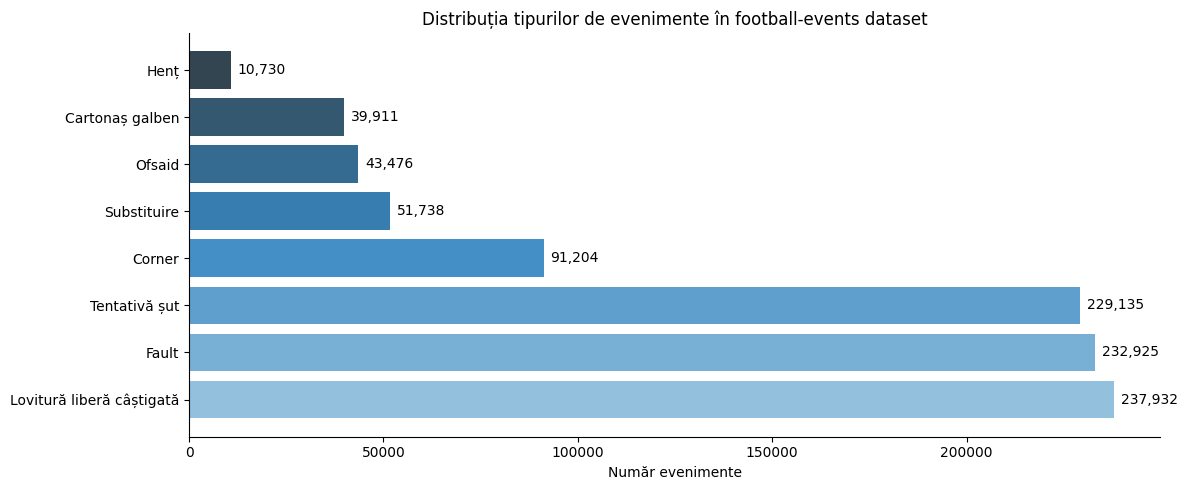

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
top = event_dist_pd.nlargest(8, 'total')
bars = ax.barh(top['denumire'], top['total'], color=sns.color_palette('Blues_d', 8))
ax.bar_label(bars, fmt='{:,.0f}', padding=5)
ax.set_xlabel('Număr evenimente')
ax.set_title('Distribuția tipurilor de evenimente în football-events dataset')
plt.tight_layout()
plt.savefig('plots/fig_event_types.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.4 Top echipe după goluri marcate — DataFrame API

Folosind DataFrame API, calculăm numărul total de goluri marcate de fiecare echipă de-a lungul perioadei analizate.


In [9]:
top_scorers = events_df \
    .filter(col('is_goal') == 1) \
    .groupBy('event_team') \
    .agg(
        count('*').alias('goluri'),
        countDistinct('id_odsp').alias('meciuri')
    ) \
    .withColumn('goluri_per_meci', spark_round(col('goluri') / col('meciuri'), 2)) \
    .orderBy(desc('goluri')) \
    .limit(15)

top_scorers.show(15, truncate=False)

+-------------------+------+-------+---------------+
|event_team         |goluri|meciuri|goluri_per_meci|
+-------------------+------+-------+---------------+
|Barcelona          |586   |185    |3.17           |
|Real Madrid        |573   |182    |3.15           |
|Bayern Munich      |453   |161    |2.81           |
|Paris Saint-Germain|447   |187    |2.39           |
|Napoli             |403   |172    |2.34           |
|Juventus           |401   |189    |2.12           |
|Borussia Dortmund  |392   |155    |2.53           |
|AS Roma            |373   |176    |2.12           |
|Lyon               |355   |167    |2.13           |
|Atletico Madrid    |347   |161    |2.16           |
|Sevilla            |330   |166    |1.99           |
|AC Milan           |329   |166    |1.98           |
|Fiorentina         |321   |157    |2.04           |
|Valencia           |314   |160    |1.96           |
|Internazionale     |312   |162    |1.93           |
+-------------------+------+-------+----------

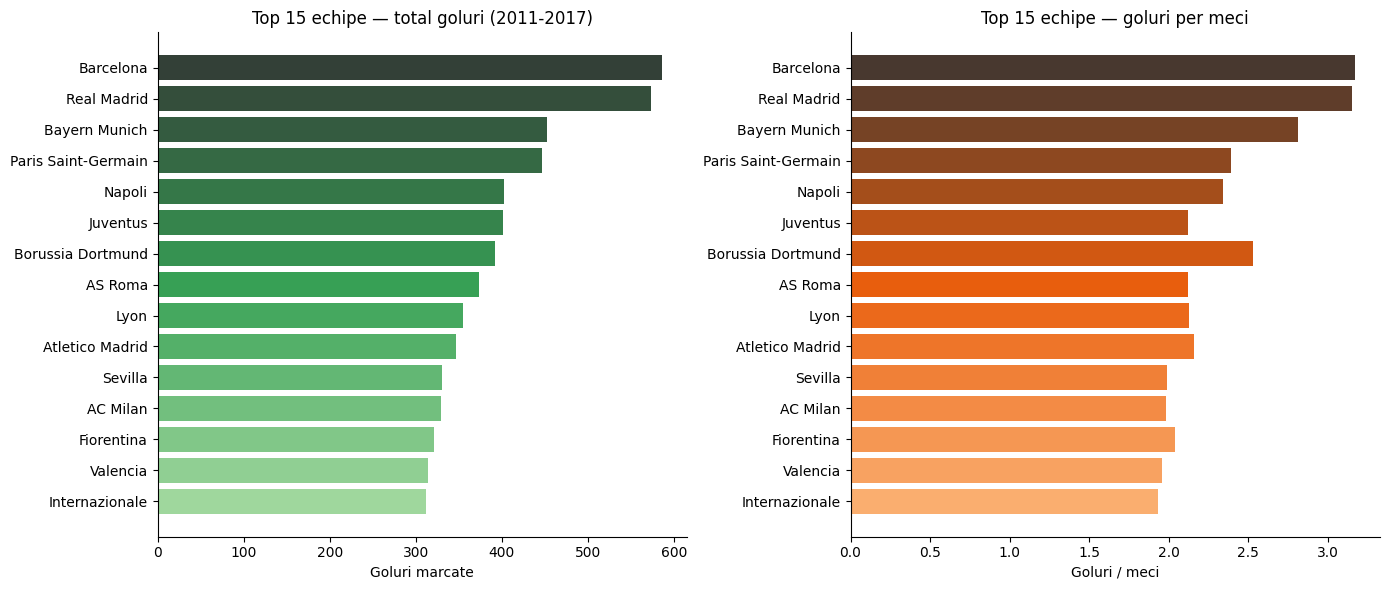

In [10]:
import os
os.makedirs('plots', exist_ok=True)

top_pd = top_scorers.toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].barh(top_pd['event_team'][::-1], top_pd['goluri'][::-1],
             color=sns.color_palette('Greens_d', 15))
axes[0].set_title('Top 15 echipe — total goluri (2011-2017)')
axes[0].set_xlabel('Goluri marcate')

axes[1].barh(top_pd['event_team'][::-1], top_pd['goluri_per_meci'][::-1],
             color=sns.color_palette('Oranges_d', 15))
axes[1].set_title('Top 15 echipe — goluri per meci')
axes[1].set_xlabel('Goluri / meci')

plt.tight_layout()
plt.savefig('plots/fig_top_teams.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.5 Rata de conversie a șuturilor pe zonă de teren — Spark SQL

Calculăm câte șuturi și câte goluri provin din fiecare zonă a terenului, obținând rata de conversie (eficiența) pentru fiecare locație.


In [11]:
location_map = {
    1: 'Jumătate atac', 2: 'Jumătate apărare', 3: 'Centru careu',
    4: 'Flanc stâng', 5: 'Flanc drept', 6: 'Unghi dificil + distanță lungă',
    7: 'Unghi dificil stânga', 8: 'Unghi dificil dreapta',
    9: 'Stânga careului', 10: 'Stânga 6 yarzi', 11: 'Dreapta careului',
    12: 'Dreapta 6 yarzi', 13: 'Distanță foarte mică',
    14: 'Punctul de penalti', 15: 'În afara careului',
    16: 'Distanță lungă', 17: '>35 yarzi', 18: '>40 yarzi', 19: 'Neînregistrat'
}

conversion_sql = spark.sql("""
    SELECT
        location,
        COUNT(*) AS total_suturi,
        SUM(is_goal) AS goluri,
        ROUND(SUM(is_goal) * 100.0 / COUNT(*), 2) AS rata_conversie
    FROM shots
    WHERE location != 19
    GROUP BY location
    HAVING COUNT(*) > 100
    ORDER BY rata_conversie DESC
""")

conv_pd = conversion_sql.toPandas()
# ROUND() din Spark SQL întoarce decimal.Decimal — cast la float pentru matplotlib/pandas
conv_pd['rata_conversie'] = conv_pd['rata_conversie'].astype(float)
conv_pd['zona'] = conv_pd['location'].map(location_map)
print(conv_pd[['zona', 'total_suturi', 'goluri', 'rata_conversie']].to_string(index=False))

                          zona  total_suturi  goluri  rata_conversie
            Punctul de penalti          2596    1989           76.62
          Distanță foarte mică          6661    3337           50.10
               Dreapta 6 yarzi          3426     702           20.49
                Stânga 6 yarzi          3492     711           20.36
                  Centru careu         69606   10713           15.39
          Unghi dificil stânga          2563     201            7.84
         Unghi dificil dreapta          2458     187            7.61
              Dreapta careului         18441    1273            6.90
               Stânga careului         19033    1234            6.48
Unghi dificil + distanță lungă          1517      43            2.83
             În afara careului         93667    2555            2.73
                     >40 yarzi           256       4            1.56
                Distanță lungă          1991      31            1.56
                     >35 yarzi    

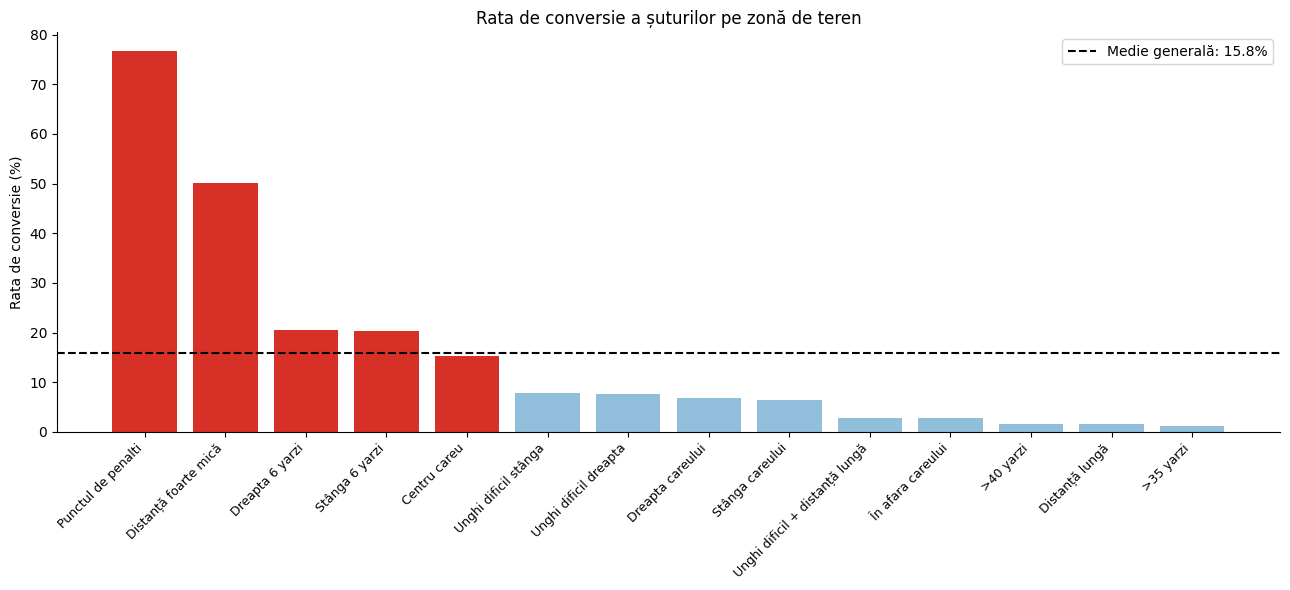

In [12]:
fig, ax = plt.subplots(figsize=(13, 6))
colors = ['#d73027' if r > 15 else '#fee090' if r > 8 else '#91bfdb'
          for r in conv_pd['rata_conversie']]
bars = ax.bar(range(len(conv_pd)), conv_pd['rata_conversie'], color=colors)
ax.set_xticks(range(len(conv_pd)))
ax.set_xticklabels(conv_pd['zona'], rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Rata de conversie (%)')
ax.set_title('Rata de conversie a șuturilor pe zonă de teren')
ax.axhline(conv_pd['rata_conversie'].mean(), color='black', linestyle='--',
           label=f'Medie generală: {conv_pd["rata_conversie"].mean():.1f}%')
ax.legend()
plt.tight_layout()
plt.savefig('plots/fig_conversion_by_zone.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.6 Distribuția golurilor în funcție de minutul meciului — DataFrame API

Analizăm distribuția temporală a golurilor pe parcursul unui meci, grupând pe intervale de 5 minute.


In [13]:
from pyspark.sql.functions import floor

goals_by_time = events_df \
    .filter((col('is_goal') == 1) & col('time').isNotNull() & (col('time') <= 95)) \
    .withColumn('interval_5min', (floor(col('time') / 5) * 5).cast('int')) \
    .groupBy('interval_5min') \
    .count() \
    .orderBy('interval_5min')

time_pd = goals_by_time.toPandas()
print('Goluri pe intervale de 5 minute (primele 20 intervale):')
print(time_pd.head(20).to_string(index=False))

Goluri pe intervale de 5 minute (primele 20 intervale):
 interval_5min  count
             0    645
             5   1083
            10   1105
            15   1190
            20   1172
            25   1181
            30   1296
            35   1172
            40   1306
            45   1488
            50   1397
            55   1440
            60   1427
            65   1343
            70   1412
            75   1418
            80   1390
            85   1468
            90   1478
            95     28


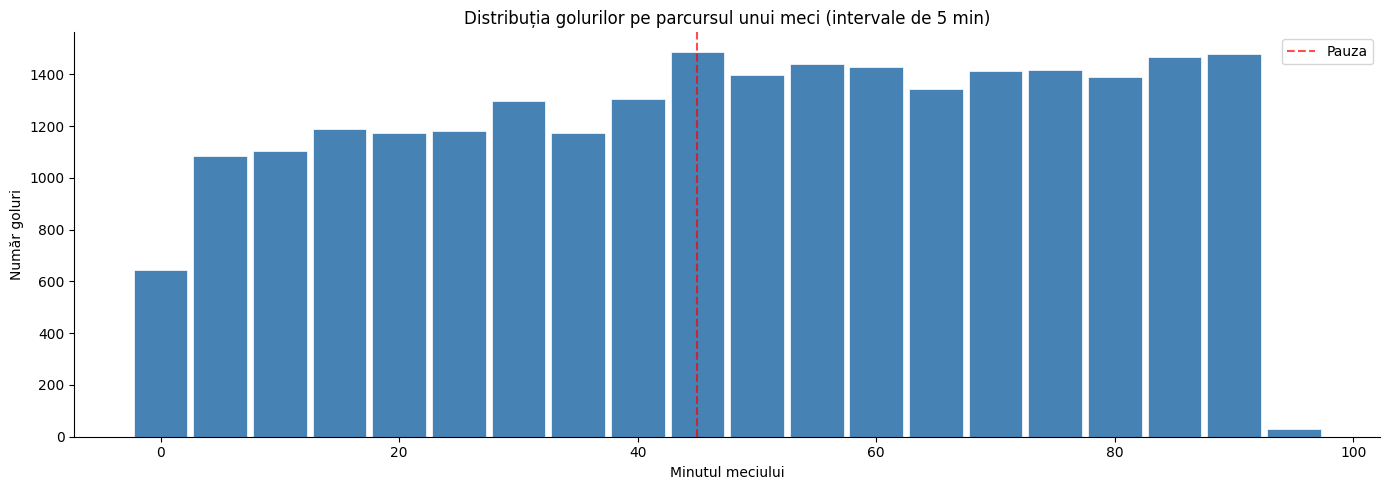

In [14]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(time_pd['interval_5min'], time_pd['count'],
       width=4.5, color='steelblue', edgecolor='white', linewidth=0.5)
ax.axvline(45, color='red', linestyle='--', alpha=0.7, label='Pauza')
ax.set_xlabel('Minutul meciului')
ax.set_ylabel('Număr goluri')
ax.set_title('Distribuția golurilor pe parcursul unui meci (intervale de 5 min)')
ax.legend()
plt.tight_layout()
plt.savefig('plots/fig_goals_by_time.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.7 Statistici per ligă și sezon — Spark SQL

Interogăm tabelul de meciuri pentru a compara intensitatea ofensivă (numărul mediu de goluri per meci) între ligi și sezoane.


In [15]:
league_map = {'D1': 'Bundesliga', 'E0': 'Premier League',
              'SP1': 'La Liga', 'I1': 'Serie A', 'F1': 'Ligue 1'}

league_stats = spark.sql("""
    SELECT
        league,
        COUNT(*) AS meciuri,
        ROUND(AVG(fthg + ftag), 3) AS medie_goluri_meci,
        MAX(fthg + ftag)            AS max_goluri_meci,
        ROUND(AVG(fthg), 3)         AS medie_goluri_acasa,
        ROUND(AVG(ftag), 3)         AS medie_goluri_deplasare,
        SUM(CASE WHEN fthg > ftag THEN 1 ELSE 0 END) AS victorii_acasa,
        SUM(CASE WHEN fthg = ftag THEN 1 ELSE 0 END) AS egaluri,
        SUM(CASE WHEN fthg < ftag THEN 1 ELSE 0 END) AS victorii_deplasare
    FROM matches
    GROUP BY league
    ORDER BY medie_goluri_meci DESC
""")

ls_pd = league_stats.toPandas()
# ROUND() din Spark SQL întoarce decimal.Decimal — cast la float pentru matplotlib/pandas
for c in ['medie_goluri_meci', 'medie_goluri_acasa', 'medie_goluri_deplasare']:
    ls_pd[c] = ls_pd[c].astype(float)
ls_pd['liga'] = ls_pd['league'].map(league_map)
print(ls_pd[['liga', 'meciuri', 'medie_goluri_meci', 'max_goluri_meci',
             'victorii_acasa', 'egaluri', 'victorii_deplasare']].to_string(index=False))

          liga  meciuri  medie_goluri_meci  max_goluri_meci  victorii_acasa  egaluri  victorii_deplasare
    Bundesliga     1690              2.882               11             768      417                 505
       La Liga     2089              2.770               12             997      500                 592
Premier League     2120              2.742               10             951      529                 640
       Serie A     2106              2.650                9             968      553                 585
       Ligue 1     2107              2.507                9             965      574                 568


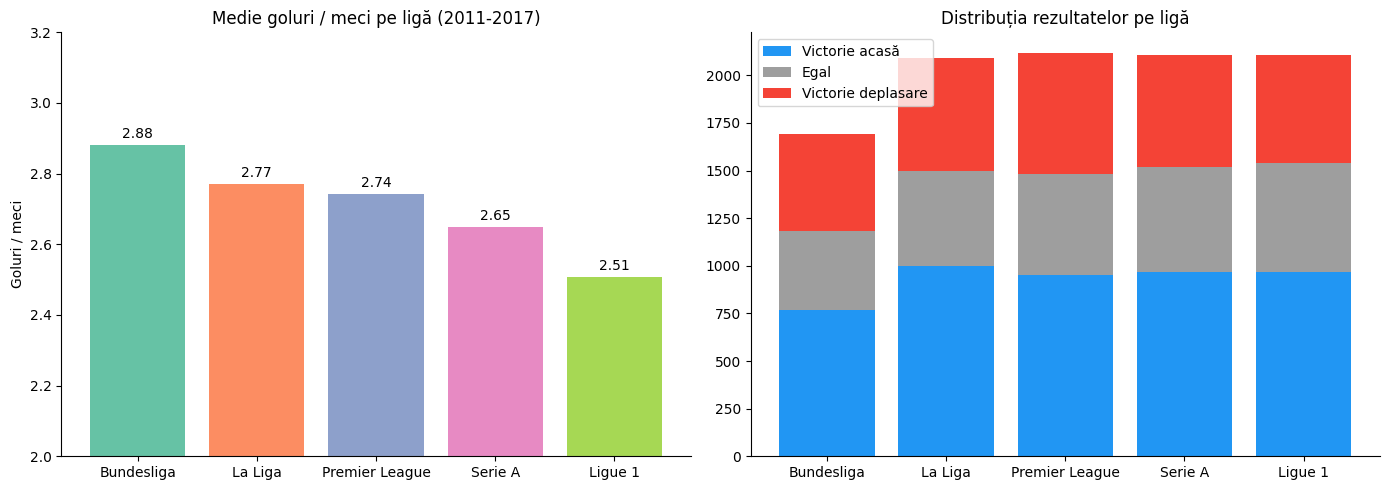

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Medie goluri per meci pe ligă
axes[0].bar(ls_pd['liga'], ls_pd['medie_goluri_meci'],
            color=sns.color_palette('Set2', 5))
axes[0].set_title('Medie goluri / meci pe ligă (2011-2017)')
axes[0].set_ylabel('Goluri / meci')
axes[0].set_ylim(2, 3.2)
for i, v in enumerate(ls_pd['medie_goluri_meci']):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

# Distribuția rezultatelor (stacked bar)
bottom_e = ls_pd['victorii_acasa']
bottom_d = ls_pd['victorii_acasa'] + ls_pd['egaluri']
axes[1].bar(ls_pd['liga'], ls_pd['victorii_acasa'], label='Victorie acasă', color='#2196F3')
axes[1].bar(ls_pd['liga'], ls_pd['egaluri'], bottom=bottom_e, label='Egal', color='#9E9E9E')
axes[1].bar(ls_pd['liga'], ls_pd['victorii_deplasare'], bottom=bottom_d,
            label='Victorie deplasare', color='#F44336')
axes[1].set_title('Distribuția rezultatelor pe ligă')
axes[1].legend()

plt.tight_layout()
plt.savefig('plots/fig_league_stats.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.8 Top jucători marcatori — DataFrame API cu join

Realizăm un join între `events_df` și `ginf_df` pe cheia `id_odsp` pentru a obține contextul ligii și sezonului pentru fiecare gol marcat.


In [17]:
top_players = events_df \
    .filter((col('is_goal') == 1) & col('player').isNotNull() & (col('player') != '')) \
    .join(ginf_df.select('id_odsp', 'league', 'season'), on='id_odsp', how='inner') \
    .groupBy('player', 'league') \
    .agg(
        count('*').alias('goluri'),
        countDistinct('id_odsp').alias('meciuri_cu_gol')
    ) \
    .orderBy(desc('goluri')) \
    .limit(20)

tp_pd = top_players.toPandas()
tp_pd['liga'] = tp_pd['league'].map(league_map)
print(tp_pd[['player', 'liga', 'goluri', 'meciuri_cu_gol']].to_string(index=False))

                  player           liga  goluri  meciuri_cu_gol
            lionel messi        La Liga     205             124
       cristiano ronaldo        La Liga     198             115
      robert lewandowski     Bundesliga     124              83
      zlatan ibrahimovic        Ligue 1     111              71
     alexandre lacazette        Ligue 1      88              65
           karim benzema        La Liga      85              68
         gonzalo higuain        Serie A      82              58
       antoine griezmann        La Liga      80              61
       antonio di natale        Serie A      76              62
           sergio aguero Premier League      75              51
          edinson cavani        Ligue 1      72              55
            mauro icardi        Serie A      72              54
            ruben castro        La Liga      69              59
      klaasjan huntelaar     Bundesliga      68              50
             luis suarez        La Liga 

## 2.9 Analiza eficienței șuturilor pe tip de acțiune — Spark SQL

Comparăm rata de conversie în funcție de situația de joc (joc deschis, fază fixă, corner, lovitură liberă) și de metoda de assist.


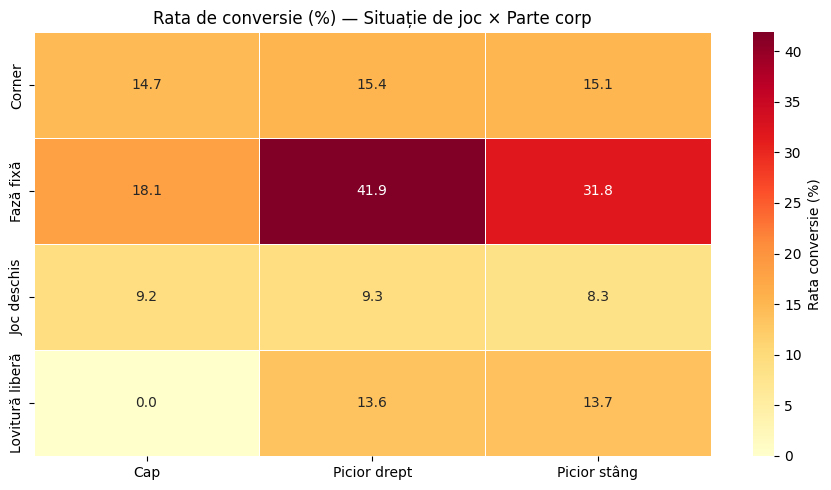

In [18]:
situation_map = {1: 'Joc deschis', 2: 'Fază fixă', 3: 'Corner', 4: 'Lovitură liberă'}
bodypart_map  = {1: 'Picior drept', 2: 'Picior stâng', 3: 'Cap'}

situation_stats = spark.sql("""
    SELECT
        situation,
        bodypart,
        COUNT(*)           AS total_suturi,
        SUM(is_goal)       AS goluri,
        ROUND(SUM(is_goal) * 100.0 / COUNT(*), 2) AS rata_conversie
    FROM shots
    WHERE situation IS NOT NULL AND bodypart IS NOT NULL
    GROUP BY situation, bodypart
    ORDER BY rata_conversie DESC
""")

sit_pd = situation_stats.toPandas()
# ROUND() din Spark SQL întoarce decimal.Decimal — cast la float pentru matplotlib/pandas
sit_pd['rata_conversie'] = sit_pd['rata_conversie'].astype(float)
sit_pd['situatie'] = sit_pd['situation'].map(situation_map)
sit_pd['parte_corp'] = sit_pd['bodypart'].map(bodypart_map)

# Pivot pentru heatmap
pivot = sit_pd.pivot_table(
    index='situatie', columns='parte_corp',
    values='rata_conversie', aggfunc='first'
)

fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Rata conversie (%)'})
ax.set_title('Rata de conversie (%) — Situație de joc × Parte corp')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('plots/fig_heatmap_conversion.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.10 Expected Goals (xG) estimat din locația șutului — Spark SQL

**Ce analizăm:** Atribuim fiecărui șut o probabilitate de gol egală cu rata istorică de conversie a zonei din care a fost executat (un model xG simplificat, bazat doar pe locație). Însumând aceste probabilități pe meci obținem *xG-ul* echipei, pe care îl comparăm cu golurile marcate efectiv.


Top 10 echipe care SUPRA-performează xG (finalizare clinică / noroc):
              event_team  meciuri  xg_mediu  goluri_reale_mediu  overperformance
               Barcelona      201     1.885               2.741            0.857
             Real Madrid      198     2.038               2.742            0.704
           Bayern Munich      179     1.928               2.419            0.491
       Borussia Dortmund      180     1.745               2.117            0.372
                  Napoli      207     1.524               1.870            0.346
     Paris Saint-Germain      208     1.703               2.005            0.302
Borussia Monchengladbach      182     1.170               1.429            0.259
                    Lyon      206     1.392               1.626            0.234
               AS Monaco      134     1.392               1.604            0.213
         Manchester City      130     1.873               2.069            0.197

Top 5 echipe care SUB-performează xG (

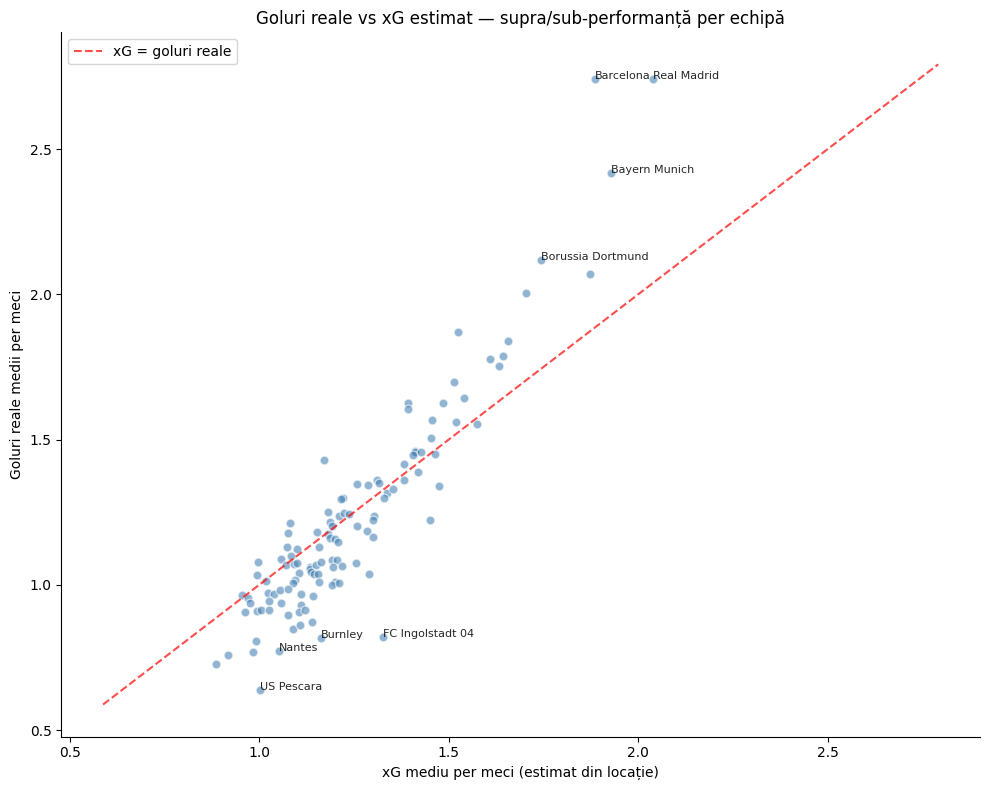

In [19]:
# xG (Expected Goals) estimat din rata istorică de conversie pe locație — Spark SQL
# Pas 1: fiecare locație primește o probabilitate empirică de gol (xG per șut)
# Pas 2: xG-ul unui meci = suma xG-urilor șuturilor; comparăm cu golurile reale
import pandas as pd

xg_analysis = spark.sql("""
    WITH loc_xg AS (
        SELECT location,
               SUM(is_goal) / COUNT(*) AS xg_per_shot
        FROM shots
        WHERE location != 19
        GROUP BY location
        HAVING COUNT(*) > 50
    ),
    match_xg AS (
        SELECT s.event_team,
               s.id_odsp,
               SUM(l.xg_per_shot) AS xg_meci,
               SUM(s.is_goal)     AS goluri_meci
        FROM shots s
        JOIN loc_xg l ON s.location = l.location
        GROUP BY s.event_team, s.id_odsp
    )
    SELECT event_team,
           COUNT(*)                                   AS meciuri,
           ROUND(AVG(xg_meci), 3)                     AS xg_mediu,
           ROUND(AVG(goluri_meci), 3)                 AS goluri_reale_mediu,
           ROUND(AVG(goluri_meci) - AVG(xg_meci), 3)  AS overperformance
    FROM match_xg
    GROUP BY event_team
    HAVING COUNT(*) >= 50
    ORDER BY overperformance DESC
""")

xg_pd = xg_analysis.toPandas()
# ROUND() din Spark SQL întoarce decimal.Decimal — cast la float pentru matplotlib/pandas
for c in ['xg_mediu', 'goluri_reale_mediu', 'overperformance']:
    xg_pd[c] = xg_pd[c].astype(float)
print('Top 10 echipe care SUPRA-performează xG (finalizare clinică / noroc):')
print(xg_pd.head(10)[['event_team', 'meciuri', 'xg_mediu',
                      'goluri_reale_mediu', 'overperformance']].to_string(index=False))
print('\nTop 5 echipe care SUB-performează xG (risipă de ocazii):')
print(xg_pd.tail(5)[['event_team', 'meciuri', 'xg_mediu',
                     'goluri_reale_mediu', 'overperformance']].to_string(index=False))

# Scatter: xG mediu vs goluri reale; linia y=x separă supra/sub-performanța
fig, ax = plt.subplots(figsize=(10, 8))
ax.scatter(xg_pd['xg_mediu'], xg_pd['goluri_reale_mediu'],
           s=40, alpha=0.6, color='steelblue', edgecolor='white')
lim_min = min(xg_pd['xg_mediu'].min(), xg_pd['goluri_reale_mediu'].min()) - 0.05
lim_max = max(xg_pd['xg_mediu'].max(), xg_pd['goluri_reale_mediu'].max()) + 0.05
ax.plot([lim_min, lim_max], [lim_min, lim_max], 'r--', alpha=0.7,
        label='xG = goluri reale')
# Adnotăm cele mai extreme echipe (supra + sub performanță)
for _, r in pd.concat([xg_pd.head(4), xg_pd.tail(4)]).iterrows():
    ax.annotate(r['event_team'], (r['xg_mediu'], r['goluri_reale_mediu']),
                fontsize=8, alpha=0.85)
ax.set_xlabel('xG mediu per meci (estimat din locație)')
ax.set_ylabel('Goluri reale medii per meci')
ax.set_title('Goluri reale vs xG estimat — supra/sub-performanță per echipă')
ax.legend()
plt.tight_layout()
plt.savefig('plots/fig_xg_vs_real.png', dpi=120, bbox_inches='tight')
plt.show()

## 2.11 Matrice de corelație între atributele șuturilor — Spark MLlib

**Ce analizăm:** Calculăm corelația Pearson între atributele numerice ale șuturilor (locație, parte corp, situație, metodă assist, fast break, plasament, minut) și ținta `is_goal`, folosind `Correlation.corr` din Spark MLlib (calcul distribuit pe vector de features, nu `pandas.corr`).


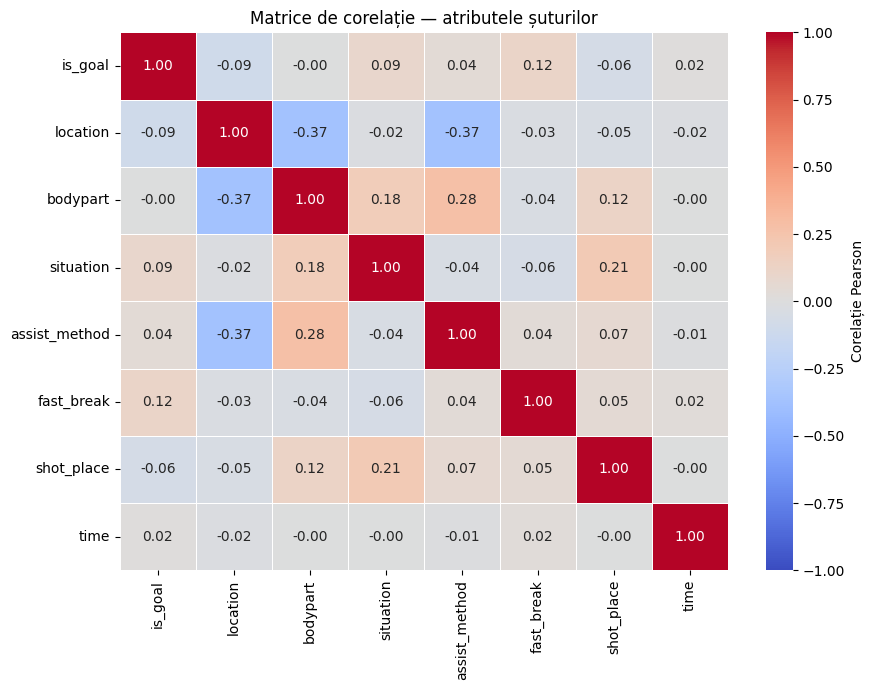

Corelația fiecărui atribut cu is_goal (sortat după |valoare|):
fast_break       0.116
location        -0.094
situation        0.089
shot_place      -0.064
assist_method    0.040
time             0.015
bodypart        -0.001


In [20]:
# Matrice de corelație Pearson între atributele șuturilor (Spark MLlib, calcul distribuit)
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation
import pandas as pd

num_cols = ['is_goal', 'location', 'bodypart', 'situation',
            'assist_method', 'fast_break', 'shot_place', 'time']

# Asamblăm coloanele într-un singur vector; handleInvalid='skip' elimină rândurile cu null
assembler = VectorAssembler(inputCols=num_cols, outputCol='features',
                            handleInvalid='skip')
vec_df = assembler.transform(shots_df.select(*num_cols))

corr_mat = Correlation.corr(vec_df, 'features', 'pearson').head()[0]
corr_pd = pd.DataFrame(corr_mat.toArray(), index=num_cols, columns=num_cols)

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_pd, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            vmin=-1, vmax=1, linewidths=0.5, ax=ax,
            cbar_kws={'label': 'Corelație Pearson'})
ax.set_title('Matrice de corelație — atributele șuturilor')
plt.tight_layout()
plt.savefig('plots/fig_correlation_matrix.png', dpi=120, bbox_inches='tight')
plt.show()

# Corelația fiecărui atribut cu is_goal, sortată după magnitudine (păstrând semnul)
goal_corr = corr_pd['is_goal'].drop('is_goal')
goal_corr = goal_corr.reindex(goal_corr.abs().sort_values(ascending=False).index)
print('Corelația fiecărui atribut cu is_goal (sortat după |valoare|):')
print(goal_corr.round(3).to_string())

## 2.12 Evoluția golurilor pe sezoane și ligi — DataFrame API

**Ce analizăm:** Media de goluri per meci, grupată pe sezon și ligă, vizualizată ca serie temporală (o linie per ligă).


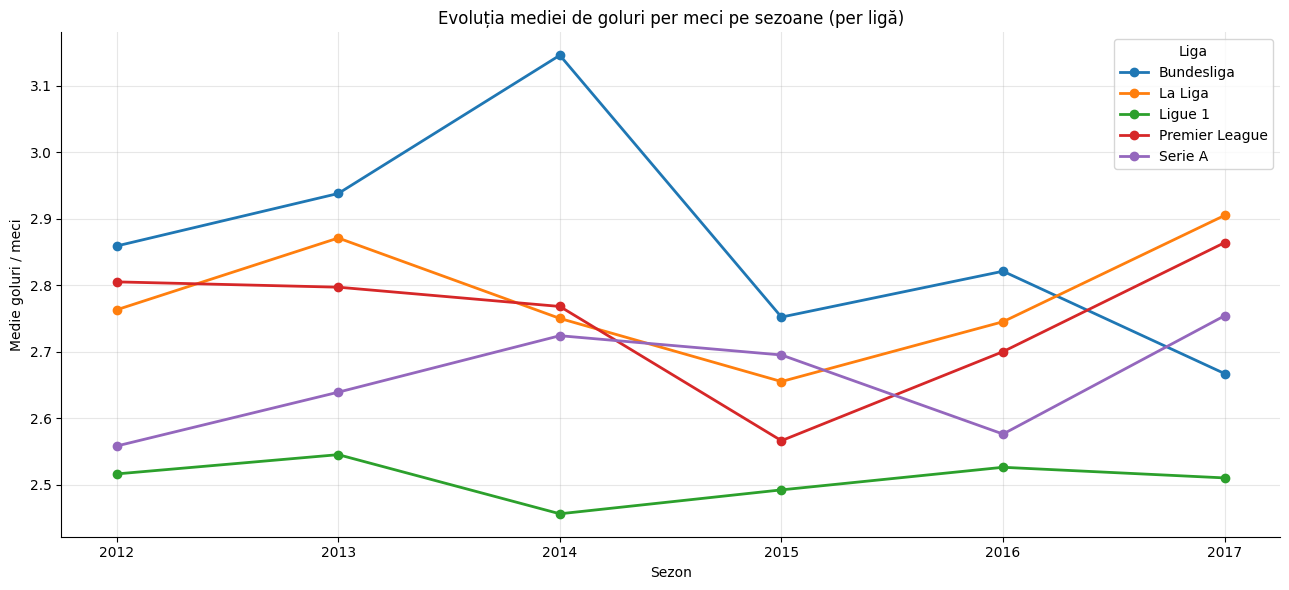

Medie goluri/meci pe sezon × ligă:
liga    Bundesliga  La Liga  Ligue 1  Premier League  Serie A
season                                                       
2012         2.859    2.763    2.516           2.805    2.558
2013         2.938    2.871    2.545           2.797    2.639
2014         3.146    2.750    2.456           2.768    2.724
2015         2.752    2.655    2.492           2.566    2.695
2016         2.821    2.745    2.526           2.700    2.576
2017         2.667    2.905    2.510           2.864    2.754


In [21]:
# Evoluția mediei de goluri per meci, pe sezoane și ligi (DataFrame API)
import pandas as pd

goals_evolution = ginf_df \
    .filter(col('season').isNotNull() & col('league').isNotNull()
            & col('fthg').isNotNull() & col('ftag').isNotNull()) \
    .withColumn('total_goluri', col('fthg') + col('ftag')) \
    .groupBy('league', 'season') \
    .agg(spark_round(avg('total_goluri'), 3).alias('medie_goluri'),
         count('*').alias('meciuri')) \
    .orderBy('season', 'league')

ge_pd = goals_evolution.toPandas()
ge_pd['liga'] = ge_pd['league'].map(league_map).fillna(ge_pd['league'])

# Pivot „long" -> „wide": un rând per sezon, o coloană per ligă (echivalent SQL PIVOT)
pivot_ev = ge_pd.pivot_table(index='season', columns='liga',
                             values='medie_goluri', aggfunc='first').sort_index()

fig, ax = plt.subplots(figsize=(13, 6))
for liga in pivot_ev.columns:
    ax.plot(pivot_ev.index.astype(str), pivot_ev[liga],
            marker='o', linewidth=2, label=liga)
ax.set_xlabel('Sezon')
ax.set_ylabel('Medie goluri / meci')
ax.set_title('Evoluția mediei de goluri per meci pe sezoane (per ligă)')
ax.legend(title='Liga')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('plots/fig_goals_evolution.png', dpi=120, bbox_inches='tight')
plt.show()

print('Medie goluri/meci pe sezon × ligă:')
print(pivot_ev.round(3).to_string())

## 2.13 Rezumat — statistici generale (Spark SQL)

O ultimă interogare SQL care rezumă datele cheie despre setul de date.


In [22]:
summary = spark.sql("""
    SELECT
        COUNT(DISTINCT m.id_odsp)          AS total_meciuri,
        COUNT(DISTINCT m.ht)               AS echipe_unice,
        COUNT(DISTINCT m.league)           AS ligi,
        COUNT(DISTINCT m.season)           AS sezoane,
        SUM(m.fthg + m.ftag)               AS total_goluri,
        ROUND(AVG(m.fthg + m.ftag), 3)    AS medie_goluri_per_meci,
        (SELECT COUNT(*) FROM events WHERE event_type = 1) AS total_suturi,
        (SELECT COUNT(*) FROM events WHERE is_goal = 1)    AS total_goluri_events
    FROM matches m
""")

print('=== Statistici generale dataset ===')
summary.show(1, vertical=True, truncate=False)

spark.stop()
print('\nSesiune Spark oprită.')

=== Statistici generale dataset ===


-RECORD 0-----------------------
 total_meciuri         | 10112  
 echipe_unice          | 147    
 ligi                  | 5      
 sezoane               | 6      
 total_goluri          | 27333  
 medie_goluri_per_meci | 2.703  
 total_suturi          | 229135 
 total_goluri_events   | 24446  




Sesiune Spark oprită.
